#### Performing Feature Selaction on A Dataset

In [492]:
import pandas as pd
import numpy as np

In [493]:
df = pd.read_csv(r"c:\Users\user\Downloads\test.csv.zip")

In [494]:
df.shape

(2947, 563)

In [495]:
df["Activity"].value_counts()

Activity
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64

In [496]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [497]:
#Separate Features and target
x=df.drop("Activity",axis=1)
y=df["Activity"]

#Encode target labels
le=LabelEncoder()
y=le.fit_transform(y)

In [498]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [499]:
print(x_train.shape)
print(x_test.shape)


(2357, 562)
(590, 562)


#### Applying Logistic Reg.....

In [500]:
log_reg=LogisticRegression(max_iter=1000)


In [501]:
log_reg.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [502]:
#make pridiction on the test size
y_pre=log_reg.predict(x_test)

In [503]:
accuracy_score(y_test,y_pre)

0.9932203389830508

In [504]:

print(classification_report(y_test, y_pre))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       106
           1       0.98      0.98      0.98       103
           2       0.98      0.98      0.98        96
           3       1.00      1.00      1.00        97
           4       1.00      1.00      1.00        83
           5       1.00      1.00      1.00       105

    accuracy                           0.99       590
   macro avg       0.99      0.99      0.99       590
weighted avg       0.99      0.99      0.99       590



In [505]:
type(x_train)

pandas.core.frame.DataFrame

#### Removing Duplicate columns

In [506]:
def get_duplicate_column(x_train):

    duplicate_column = {}
    seen_column = {}

    for column in x_train.columns:

        current_column = x_train[column]

        try:
            current_column_hash = current_column.values.tobytes()

        except AttributeError:
            current_column_hash = current_column.to_string().encode()

        if current_column_hash in seen_column:

            if seen_column[current_column_hash] in duplicate_column:
                duplicate_column[seen_column[current_column_hash]].append(column)

            else:
                duplicate_column[seen_column[current_column_hash]] = [column]

        else:
            seen_column[current_column_hash] = column

    return duplicate_column
duplicate = get_duplicate_column(x_train)

In [507]:


print(duplicate)
#pd.DataFrame(duplicate.keys(),columns=["Duplicate_Columns"])

{'tBodyAccMag-mean()': ['tBodyAccMag-sma()', 'tGravityAccMag-mean()', 'tGravityAccMag-sma()'], 'tBodyAccMag-std()': ['tGravityAccMag-std()'], 'tBodyAccMag-mad()': ['tGravityAccMag-mad()'], 'tBodyAccMag-max()': ['tGravityAccMag-max()'], 'tBodyAccMag-min()': ['tGravityAccMag-min()'], 'tBodyAccMag-energy()': ['tGravityAccMag-energy()'], 'tBodyAccMag-iqr()': ['tGravityAccMag-iqr()'], 'tBodyAccMag-entropy()': ['tGravityAccMag-entropy()'], 'tBodyAccMag-arCoeff()1': ['tGravityAccMag-arCoeff()1'], 'tBodyAccMag-arCoeff()2': ['tGravityAccMag-arCoeff()2'], 'tBodyAccMag-arCoeff()3': ['tGravityAccMag-arCoeff()3'], 'tBodyAccMag-arCoeff()4': ['tGravityAccMag-arCoeff()4'], 'tBodyAccJerkMag-mean()': ['tBodyAccJerkMag-sma()'], 'tBodyGyroMag-mean()': ['tBodyGyroMag-sma()'], 'tBodyGyroJerkMag-mean()': ['tBodyGyroJerkMag-sma()'], 'fBodyAccMag-mean()': ['fBodyAccMag-sma()'], 'fBodyBodyAccJerkMag-mean()': ['fBodyBodyAccJerkMag-sma()'], 'fBodyBodyGyroMag-mean()': ['fBodyBodyGyroMag-sma()'], 'fBodyBodyGyroJerk

In [508]:
pd.DataFrame(x_train)
pd.DataFrame(x_test)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
565,0.200467,-0.026279,-0.086678,-0.396860,0.033448,-0.596704,-0.418465,0.020370,-0.576275,-0.115401,...,-0.363179,-0.693328,0.627971,-0.060001,0.859675,-0.802659,-0.893777,0.123948,-0.055003,4
1220,0.275680,-0.020413,-0.124188,-0.996673,-0.987446,-0.986685,-0.996855,-0.987414,-0.987153,-0.940966,...,-0.621275,-0.887168,-0.066898,0.032218,-0.494242,0.284878,-0.759148,0.238368,0.110300,12
1677,0.274629,0.002954,-0.117819,-0.283561,0.113636,-0.156525,-0.346340,0.117079,-0.086709,-0.054044,...,-0.592342,-0.837790,0.158464,0.456646,-0.812556,0.450117,-0.504724,0.311719,0.287151,13
1577,0.268009,-0.020608,-0.102512,-0.984980,-0.963945,-0.978984,-0.987515,-0.961465,-0.975730,-0.924179,...,0.322867,0.031538,-0.086479,0.193677,0.773891,0.236832,0.340268,-0.193068,-0.770065,13
2834,0.267003,-0.016659,-0.106948,-0.958097,-0.985626,-0.977424,-0.960699,-0.985140,-0.973546,-0.906325,...,-0.467569,-0.757963,-0.066887,-0.140160,-0.412443,-0.542977,0.481395,-0.449344,-0.551133,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,0.278964,-0.036612,-0.113213,-0.976533,-0.754065,-0.854484,-0.979384,-0.740275,-0.854264,-0.907082,...,0.195610,-0.224895,0.011495,-0.103647,0.278913,0.021661,-0.934156,0.077862,-0.027654,12
2560,0.303065,0.002404,-0.084307,-0.012065,0.391696,-0.224547,-0.098529,0.468728,-0.214721,0.177449,...,-0.731808,-0.922922,0.026147,-0.111198,-0.947790,-0.088208,-0.455923,0.472754,-0.009837,20
2936,0.277271,0.001084,-0.074001,-0.068523,-0.245059,-0.144552,-0.148731,-0.303187,-0.198912,0.402615,...,0.160861,-0.125531,0.133749,0.882511,-0.994293,0.475236,-0.803914,0.196823,0.114498,24
1412,0.278920,-0.034655,-0.103171,-0.989859,-0.948605,-0.977665,-0.990839,-0.947759,-0.975824,-0.931901,...,-0.569780,-0.866271,0.002141,-0.257269,0.124942,-0.441309,-0.923492,0.089880,0.074447,12


In [509]:
print(type(x_train))
print(x_train.head())
print(x_train.columns)
print(duplicate.keys())

<class 'pandas.core.frame.DataFrame'>
      tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
2665           0.288587          -0.015632          -0.113756   
2798           0.276631          -0.016829          -0.106878   
456            0.271751          -0.052302          -0.132822   
462            0.279018          -0.020843          -0.087746   
2178           0.227433          -0.030673          -0.095109   

      tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  \
2665         -0.983521         -0.987283         -0.990542         -0.984143   
2798         -0.995295         -0.988179         -0.977193         -0.996198   
456          -0.200641         -0.047202         -0.371207         -0.314260   
462          -0.178064          0.059195         -0.396999         -0.297581   
2178         -0.402532         -0.163684         -0.298333         -0.462332   

      tBodyAcc-mad()-Y  tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  \
2665         -0.987571 

In [510]:
x_train=pd.DataFrame(x_train).drop(columns=duplicate.keys())

x_test=pd.DataFrame(x_test).drop(columns=duplicate.keys())

#### After removing duplicate df shape is.................

In [511]:
#(2357, 562) befor
# 19 duplicate columns removed
x_train.shape

(2357, 543)

In [512]:
x_test.shape

(590, 543)

#### now Performing variance Threshhold

In [513]:
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.05)

x_train_new = sel.fit_transform(x_train)
x_test_new = sel.transform(x_test)

print("Train Shape :", x_train_new.shape)
print("Test Shape :", x_test_new.shape)

print("Selected Features :", sel.get_support().sum())

Train Shape : (2357, 332)
Test Shape : (590, 332)
Selected Features : 332


In [514]:
selected_features = x_train.columns[sel.get_support()]

print(selected_features)

Index(['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z',
       'tBodyAcc-min()-X',
       ...
       'fBodyBodyGyroJerkMag-skewness()', 'fBodyBodyGyroJerkMag-kurtosis()',
       'angle(tBodyAccMean,gravity)', 'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject'],
      dtype='object', length=332)


In [515]:
x_train = pd.DataFrame(x_train_new, columns=selected_features)
x_test = pd.DataFrame(x_test_new, columns=selected_features)

In [516]:
print(type(x_train))
print(type(x_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


#### Correlation

In [517]:
import pandas as pd

corr_matrix = x_train.corr(numeric_only=True)

print(corr_matrix)

                                      tBodyAcc-std()-X  tBodyAcc-std()-Y  \
tBodyAcc-std()-X                              1.000000          0.909397   
tBodyAcc-std()-Y                              0.909397          1.000000   
tBodyAcc-std()-Z                              0.893998          0.872869   
tBodyAcc-mad()-X                              0.998824          0.907561   
tBodyAcc-mad()-Y                              0.903820          0.997915   
...                                                ...               ...   
angle(tBodyGyroJerkMean,gravityMean)         -0.048147         -0.029263   
angle(X,gravityMean)                         -0.381541         -0.384089   
angle(Y,gravityMean)                          0.388033          0.455693   
angle(Z,gravityMean)                          0.382227          0.402417   
subject                                      -0.079096         -0.044963   

                                      tBodyAcc-std()-Z  tBodyAcc-mad()-X  \
tBodyAcc-st

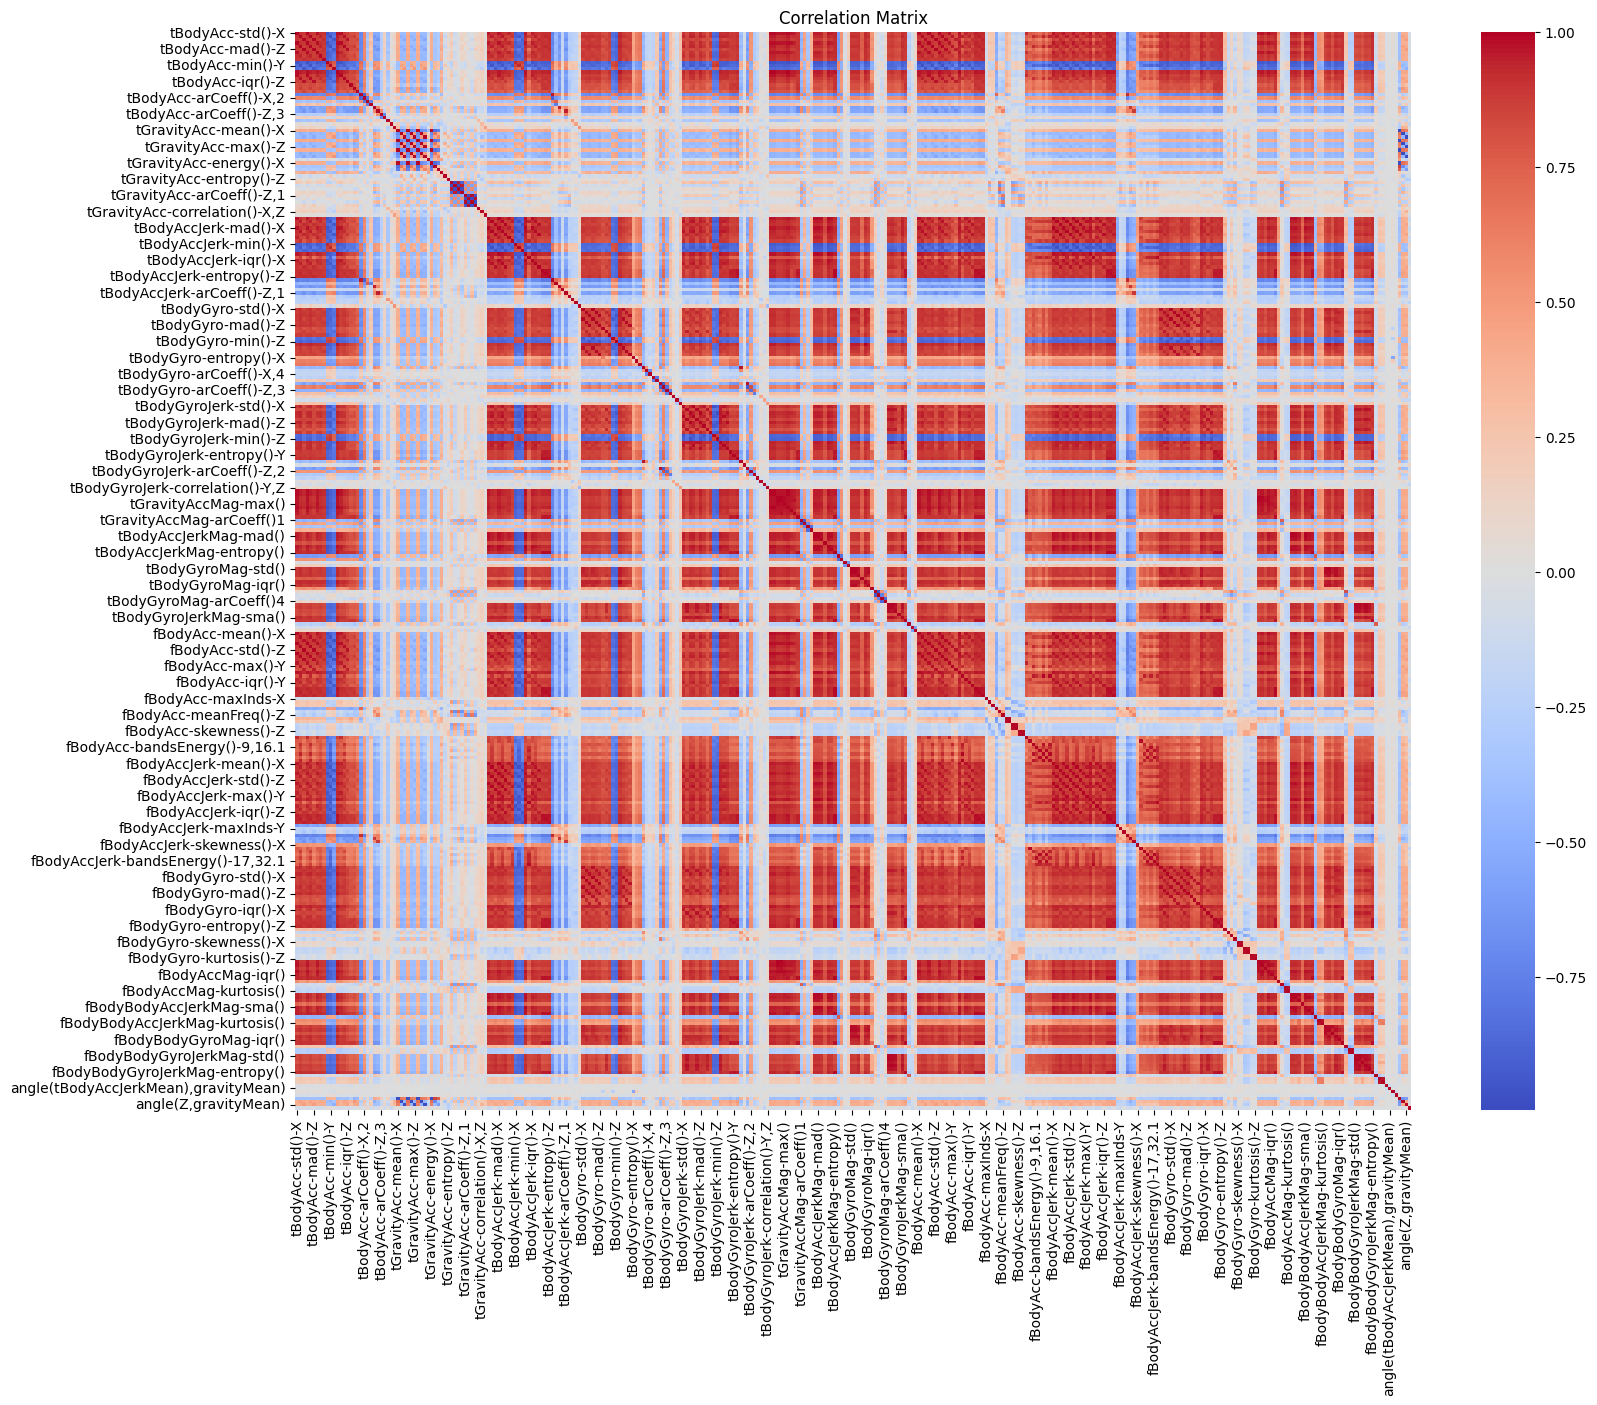

In [518]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

3. Highly Correlated Features Remove (Threshold = 0.95)

In [519]:
column=corr_matrix.columns
column_to_drop = []
#loop over the columns of the correlation matrix
for i in range(len(column)):
    for j in range(i+1,len(column)):
        if corr_matrix.loc[column[i], column[j]] > 0.95:
            column_to_drop.append(column[j])
print(len(column_to_drop))

1527


In [520]:
columns_to_drop = set(column_to_drop)

In [521]:
x_train.drop(columns=columns_to_drop, inplace=True) 
x_test.drop(columns=columns_to_drop, inplace=True)

In [522]:
print("New Train Shape :", x_train.shape)
print("New Test Shape  :", x_test.shape)

New Train Shape : (2357, 149)
New Test Shape  : (590, 149)


### ANOVA

In [523]:
## Koi bhi column le le lete hai jo bcha hai
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest
#f_classif perform anova internly
sel=SelectKBest(score_func=f_classif, k=100)
sel.fit(x_train, y_train)
column=x_train.columns[sel.get_support()]

In [524]:
column

Index(['tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X',
       'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-entropy()-X',
       'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z',
       'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2',
       'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4',
       'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Z,1',
       'tBodyAcc-correlation()-X,Y', 'tGravityAcc-mean()-X',
       'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z', 'tGravityAcc-sma()',
       'tGravityAcc-energy()-Y', 'tGravityAcc-energy()-Z',
       'tGravityAcc-entropy()-X', 'tGravityAcc-arCoeff()-Y,1',
       'tGravityAcc-arCoeff()-Y,2', 'tGravityAcc-arCoeff()-Z,1',
       'tGravityAcc-arCoeff()-Z,2', 'tBodyAccJerk-std()-Z',
       'tBodyAccJerk-min()-X', 'tBodyAccJerk-min()-Y', 'tBodyAccJerk-min()-Z',
       'tBodyAccJerk-energy()-Y', 'tBodyAccJerk-entropy()-X',
       'tBodyAccJerk-arCoeff()-X,3', '

In [525]:
x_train=sel.transform(x_train)
x_test=sel.transform(x_test)
x_train=pd.DataFrame(x_train, columns=column)
x_test=pd.DataFrame(x_test, columns=column)

In [526]:
print(x_train.shape)
print(x_test.shape)


(2357, 100)
(590, 100)


In [527]:
log_reg=LogisticRegression(max_iter=1000)
log_reg.fit(x_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [528]:
y_pred=log_reg.predict(x_test)

In [529]:
accuracy_score(y_test,y_pred)

0.9813559322033898

### Conclusion
Conclusion is that 564 column give 99% accuracy 
and 100 column give also 98% accuracy than 

thats why feature selection is most import to perform 